In [1]:
from collections import Counter, defaultdict
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Analysis the consistency of cell types

In [2]:
s1 = pd.read_csv("results/h5ad_clustered/Blastocyst.gene_based.obs.csv", index_col=0)["CellType"]
s2 = pd.read_csv("results/h5ad_clustered/Blastocyst.transcript_based.obs.csv", index_col=0)["CellType"]
s1.name = "CellType_GeneBased"
s2.name = "CellType_TranscriptBased"
d = pd.concat([s1, s2], axis=1, join="inner")
cts = []
for ct1, ct2 in d[["CellType_GeneBased", "CellType_TranscriptBased"]].values:
    cts.append("Conflict" if ct1 != ct2 else ct1)
d["CellType_Consensus"] = cts
d.head()

,CellType_GeneBased,CellType_TranscriptBased,CellType_Consensus
Cell,,,
20220729_Blastocyst.C01.MouseBlastocyst_s4U_100uM_180min,TE-1,TE-1,TE-1
20220729_Blastocyst.C02.MouseBlastocyst_s4U_100uM_180min,TE-2,TE-2,TE-2
20220729_Blastocyst.C03.MouseBlastocyst_s4U_100uM_180min,ICM-1,ICM-1,ICM-1
20220729_Blastocyst.C04.MouseBlastocyst_s4U_100uM_180min,ICM-1,ICM-1,ICM-1
20220729_Blastocyst.C05.MouseBlastocyst_s4U_100uM_180min,ICM-1,ICM-1,ICM-1


In [3]:
for k, v in sorted(Counter(d["CellType_GeneBased"]).items()):
    print(v, k, sep="\t")

427	EPI
306	ICM-1
561	ICM-2
241	PE
230	TE-1
263	TE-2
254	muralTE
253	polarTE


In [4]:
for k, v in sorted(Counter(d["CellType_TranscriptBased"]).items()):
    print(v, k, sep="\t")

424	EPI
549	ICM-1
341	ICM-2
248	PE
168	TE-1
323	TE-2
240	muralTE
242	polarTE


In [5]:
for k, v in sorted(Counter(d["CellType_Consensus"]).items()):
    print(v, k, sep="\t")

451	Conflict
414	EPI
279	ICM-1
298	ICM-2
236	PE
163	TE-1
247	TE-2
222	muralTE
225	polarTE


In [6]:
n1 = 0
n2 = 0
for ct1, ct2 in d[["CellType_GeneBased", "CellType_TranscriptBased"]].values:
    if ct1 == ct2:
        n1 += 1
        n2 += 1
    elif ct1.startswith("ICM-") and ct2.startswith("ICM-"):
        n2 += 1
print("Identical (strict): %d (%.2f%%)" % (n1, n1 * 100 / len(d)))
print("Identical (loose): %d (%.2f%%)" % (n2, n2 * 100 / len(d)))

Identical (strict): 2084 (82.21%)
Identical (loose): 2354 (92.86%)


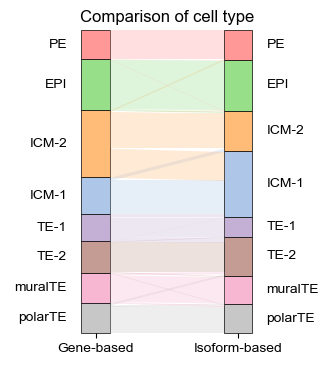

In [7]:
cts1 = ['polarTE', 'muralTE', 'TE-2', 'TE-1', 'ICM-1', 'ICM-2', 'EPI', 'PE']

cmap = plt.colormaps["tab20"]
colors1=[cmap(15), cmap(13), cmap(11), cmap(9), cmap(1), cmap(3), cmap(5), cmap(7)]

data = dict()
counter = Counter(d["CellType_GeneBased"])
bottom = 0
for k in cts1:
    v = counter[k]
    data[k] = dict()
    data[k]["Count"] = v
    data[k]["Bottom"] = bottom
    data[k]["Offset"] = 0
    bottom += v
data1 = data

cts2, colors2 = cts1, colors1
counter = Counter(d["CellType_TranscriptBased"])
data = dict()
bottom = 0
for k in cts2:
    v = counter[k]
    data[k] = dict()
    data[k]["Count"] = v
    data[k]["Bottom"] = bottom
    data[k]["Offset"] = 0
    bottom += v
data2 = data

data = defaultdict(list)
for ct1, ct2 in d[["CellType_GeneBased", "CellType_TranscriptBased"]].values:
    data[ct1].append(ct2)
    
plt.figure(figsize=(3.5, 3.75))
plt.title("Comparison of cell type")
w = 0.2
    
for i, k in enumerate(cts1):
    v = data1[k]
    x = 0
    b = v["Bottom"]
    h = v["Count"]
    plt.bar([x], h, bottom=b, width=w, lw=0.5, edgecolor="black", color=colors1[i], clip_on=False)
    plt.text(x - w/2 - 0.1, h / 2 + b, k, ha="right", va="center")
    
for i, k in enumerate(cts2):
    v = data2[k]
    x = 1
    b = v["Bottom"]
    h = v["Count"]
    plt.bar([x], h, bottom=b, width=w, lw=0.5, edgecolor="black", color=colors2[i], clip_on=False)
    plt.text(x + w/2 + 0.1, h / 2 + b, k, ha="left", va="center")
    
for i, k1 in enumerate(cts1):
    v1 = data[k1]
    counter = Counter(v1)
    ks = list(sorted(counter.keys(), key=lambda item: cts2.index(item)))
    for k2 in ks:
        h = counter[k2]

        y1 = data1[k1]["Bottom"] + data1[k1]["Offset"]
        y2 = y1 + h
        data1[k1]["Offset"] += h
        
        y3 = data2[k2]["Bottom"] + data2[k2]["Offset"]
        y4 = y3 + h
        data2[k2]["Offset"] += h
        
        # print(y1, y2, y3, y4)
        x1 = 0 + w / 2
        x2 = 1 - w / 2
        plt.fill_between([x1, x2], [y1, y3], [y2, y4], alpha=0.3, lw=0, color=colors1[i])
    
plt.xlim(0 - 0.6, 1 + 0.6)
plt.ylim(0, len(d))
plt.xticks([0, 1], ["Gene-based", "Isoform-based"])
plt.yticks([])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/consistency_of_cell_type.pdf", dpi=300)
plt.show()
plt.close()

In [8]:
d.to_csv("results/h5ad_consensus/consistency_of_cell_type.csv")

# 2. Update H5AD for consistency cell types

In [9]:
d = pd.read_csv("results/h5ad_consensus/consistency_of_cell_type.csv", index_col=0)

In [10]:
adata1 = sc.read_h5ad("results/h5ad_clustered/Blastocyst.gene_based.h5ad")
adata2 = sc.read_h5ad("results/h5ad_clustered/Blastocyst.transcript_based.h5ad")

In [11]:
adata1.obs["CellType"] = d["CellType_Consensus"]
adata2.obs["CellType"] = d["CellType_Consensus"]

In [12]:
adata1.write_h5ad("results/h5ad_consensus/Blastocyst.gene_based.h5ad", compression="gzip")
adata2.write_h5ad("results/h5ad_consensus/Blastocyst.transcript_based.h5ad", compression="gzip")
adata1.obs.to_csv("results/h5ad_consensus/Blastocyst.gene_based.obs.csv")
adata2.obs.to_csv("results/h5ad_consensus/Blastocyst.transcript_based.obs.csv")